# FitSmart - AI Food Recognition Model
**Tim CC26-PSU394 | AI Engineer: Muhammad Rafif Hadziq**

Pipeline:
1. Setup & konfigurasi
2. Load dataset + augmentasi
3. Bangun model (TF Functional API + Custom Components)
4. Training + Custom Callback
5. Evaluasi performa
6. Export model (.keras & SavedModel)
7. Inference sederhana

In [1]:
!pip install -q tensorflow gdown Pillow scikit-learn seaborn

In [2]:
import os, json, zipfile, shutil, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from pathlib import Path
import gdown

warnings.filterwarnings('ignore')
print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {tf.config.list_physical_devices('GPU')}")

TensorFlow version : 2.20.0
GPU available      : []


In [3]:
# Konfigurasi
BASE_DIR    = '/content/fitsmart'
IMAGES_DIR  = f'{BASE_DIR}/images'
OUTPUT_DIR  = f'{BASE_DIR}/output'
MODEL_DIR   = f'{BASE_DIR}/model'

URL_IMAGES_ZIP    = 'https://drive.google.com/uc?id=1fTIbuFDclnZobr0_EQG9M6elgD-pJyh4'
URL_NUTRITION_CSV = 'https://drive.google.com/uc?export=download&id=1KSpvR7QK7bOBGHK0JPe4Dlpbh3unqnjb'

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 30
LR         = 1e-3
SEED       = 42

for d in [BASE_DIR, IMAGES_DIR, OUTPUT_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)
print("Konfigurasi berhasil")

Konfigurasi berhasil


## 1. Download & Load Dataset

In [4]:
ZIP_PATH = f'{BASE_DIR}/images.zip'

if not any(Path(IMAGES_DIR).iterdir()):
    print("Downloading dataset gambar...")
    gdown.download(URL_IMAGES_ZIP, ZIP_PATH, quiet=False)
    print("Extracting...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(IMAGES_DIR)
    os.remove(ZIP_PATH)

    # Rapikan folder container
    extracted = [d for d in Path(IMAGES_DIR).iterdir() if d.is_dir()]
    if len(extracted) == 1 and len(list(extracted[0].iterdir())) > 1:
        inner = extracted[0]
        for item in inner.iterdir():
            shutil.move(str(item), IMAGES_DIR)
        inner.rmdir()
else:
    print("Dataset sudah tersedia, skip download.")

n_classes = len([d for d in Path(IMAGES_DIR).iterdir() if d.is_dir()])
print(f"Total kelas ditemukan: {n_classes}")

Downloading...
From (original): https://drive.google.com/uc?id=1fTIbuFDclnZobr0_EQG9M6elgD-pJyh4
From (redirected): https://drive.google.com/uc?id=1fTIbuFDclnZobr0_EQG9M6elgD-pJyh4&confirm=t&uuid=775ab3c3-84df-4f95-864f-8088b62db67a
To: /content/fitsmart/images.zip
100%|██████████| 534M/534M [00:05<00:00, 105MB/s]


Extracting...
Total kelas ditemukan: 24


In [5]:
# Load class mapping dari output EDA (Dataset_FitSmart.ipynb)
CLASS_MAP_PATH = f'{OUTPUT_DIR}/class_mapping.json'

# Fallback: generate dari folder gambar
if not os.path.exists(CLASS_MAP_PATH):
    print("class_mapping.json tidak ditemukan, generate dari folder...")
    labels = sorted([d.name for d in Path(IMAGES_DIR).iterdir() if d.is_dir()])
    mapping_fb = {
        "n_classes": len(labels),
        "cls2idx":   {l: i for i, l in enumerate(labels)},
        "idx2cls":   {str(i): l for i, l in enumerate(labels)},
        "nutrition": {}
    }
    with open(CLASS_MAP_PATH, 'w') as f:
        json.dump(mapping_fb, f, indent=2, ensure_ascii=False)

with open(CLASS_MAP_PATH) as f:
    MAPPING = json.load(f)

N_CLASSES = MAPPING["n_classes"]
IDX2CLS   = MAPPING["idx2cls"]
CLS2IDX   = MAPPING["cls2idx"]
NUTRITION = MAPPING.get("nutrition", {})

print(f"N_CLASSES : {N_CLASSES}")
print(f"Contoh label: {list(CLS2IDX.keys())[:5]}")

class_mapping.json tidak ditemukan, generate dari folder...
N_CLASSES : 24
Contoh label: ['Ayam Goreng', 'Ikan Goreng', 'Mie Goreng', 'alpukat', 'apel']


## 2. tf.data Pipeline (Augmentasi + Split 80/20)

In [6]:
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    IMAGES_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    IMAGES_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False,
)

CLASS_NAMES = train_ds_raw.class_names
print(f"Kelas ({len(CLASS_NAMES)}): {CLASS_NAMES[:5]}...")
print(f"Train batches : {len(train_ds_raw)}")
print(f"Val   batches : {len(val_ds_raw)}")

Found 4231 files belonging to 24 classes.
Using 3385 files for training.
Found 4231 files belonging to 24 classes.
Using 846 files for validation.
Kelas (24): ['Ayam Goreng', 'Ikan Goreng', 'Mie Goreng', 'alpukat', 'apel']...
Train batches : 106
Val   batches : 27


In [7]:
# Augmentasi (hanya saat training)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

AUTOTUNE = tf.data.AUTOTUNE

def preprocess_train(image, label):
    image = data_augmentation(image, training=True)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def preprocess_val(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = train_ds_raw.map(preprocess_train, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds   = val_ds_raw.map(preprocess_val,   num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

print("Pipeline data siap (augmented + prefetched)")

Pipeline data siap (augmented + prefetched)


## 3. Komponen Kustom (Main Quest Checklist)

Tiga komponen kustom diimplementasikan sesuai checklist MVP:

| No | Komponen | Nama |
|----|----------|------|
| 1 | **Custom Layer** | `ChannelAttention` - Squeeze-and-Excitation block |
| 2 | **Custom Loss** | `FocalLoss` - menangani class imbalance |
| 3 | **Custom Callback** | `PerformanceGuardCallback` - monitoring & auto-stop |

In [8]:
# ============================================================
# Custom Layer: Channel Attention (SE Block)
# ============================================================
class ChannelAttention(layers.Layer):
    """Squeeze-and-Excitation block: memperkuat fitur penting per channel."""

    def __init__(self, reduction_ratio=16, **kwargs):
        super().__init__(**kwargs)
        self.reduction_ratio = reduction_ratio

    def build(self, input_shape):
        channels = input_shape[-1]
        reduced  = max(1, channels // self.reduction_ratio)
        self.gap     = layers.GlobalAveragePooling2D()
        self.fc1     = layers.Dense(reduced, activation="relu")
        self.fc2     = layers.Dense(channels, activation="sigmoid")
        self.reshape = layers.Reshape((1, 1, channels))
        super().build(input_shape)

    def call(self, inputs):
        x = self.gap(inputs)     # (B, C)
        x = self.fc1(x)          # (B, C/r)
        x = self.fc2(x)          # (B, C)
        x = self.reshape(x)      # (B, 1, 1, C)
        return inputs * x        # channel-wise reweighting

    def get_config(self):
        config = super().get_config()
        config.update({"reduction_ratio": self.reduction_ratio})
        return config

print("ChannelAttention (Custom Layer) didefinisikan")

ChannelAttention (Custom Layer) didefinisikan


In [19]:
# ============================================================
# Custom Loss: Focal Loss (Updated for Deserialization)
# ============================================================
class FocalLoss(keras.losses.Loss):
    """
    Focal Loss untuk class-imbalanced dataset.
    """

    # FIX: Added **kwargs to catch the 'reduction' parameter Keras passes during loading
    def __init__(self, gamma=2.0, alpha=0.25, name="focal_loss", **kwargs):
        super().__init__(name=name, **kwargs)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        y_one_hot = tf.cast(y_true, tf.float32)
        y_pred    = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_ent = -y_one_hot * tf.math.log(y_pred)
        p_t       = tf.reduce_sum(y_one_hot * y_pred, axis=-1)
        focal_w   = self.alpha * tf.pow(1.0 - p_t, self.gamma)

        loss = focal_w * tf.reduce_sum(cross_ent, axis=-1)
        return tf.reduce_mean(loss)

    def get_config(self):
        config = super().get_config()
        config.update({"gamma": self.gamma, "alpha": self.alpha})
        return config

print("FocalLoss (Custom Loss) didefinisikan ulang")

FocalLoss (Custom Loss) didefinisikan ulang


In [10]:
# ============================================================
# Custom Callback: PerformanceGuardCallback
# ============================================================
class PerformanceGuardCallback(callbacks.Callback):
    """
    Custom callback yang:
    - Mencetak progress bar akurasi tiap epoch
    - Auto-stop jika val_accuracy >= target selama N epoch berturut
    - Melaporkan status MVP (acc >= 85%) di akhir training
    """

    def __init__(self, target_acc=0.90, patience=4, log_every=1):
        super().__init__()
        self.target_acc  = target_acc
        self.patience    = patience
        self.log_every   = log_every
        self.wait        = 0
        self.best_acc    = 0.0

    def on_epoch_end(self, epoch, logs=None):
        logs    = logs or {}
        val_acc = logs.get("val_accuracy", 0)
        tr_acc  = logs.get("accuracy", 0)

        if (epoch + 1) % self.log_every == 0:
            filled = int(val_acc * 20)
            bar    = "#" * filled + "." * (20 - filled)
            print(f"  [Ep {epoch+1:03d}] train={tr_acc:.4f} | val={val_acc:.4f} |{bar}|")

        if val_acc >= self.target_acc:
            self.wait += 1
            if self.wait >= self.patience:
                print(f"\n[INFO] Target {self.target_acc:.0%} tercapai {self.patience}x berturut. Training dihentikan.")
                self.model.stop_training = True
        else:
            self.wait = 0

        self.best_acc = max(self.best_acc, val_acc)

    def on_train_end(self, logs=None):
        status = "LULUS" if self.best_acc >= 0.85 else "BELUM LULUS"
        print(f"\n{'='*52}")
        print(f"  TRAINING SELESAI")
        print(f"  Best val_accuracy : {self.best_acc:.4f}  ({self.best_acc*100:.2f}%)")
        print(f"  Status MVP (>=85%): {status}")
        print(f"{'='*52}")

print("PerformanceGuardCallback (Custom Callback) didefinisikan")

PerformanceGuardCallback (Custom Callback) didefinisikan


## 4. Bangun Model - TensorFlow Functional API

In [11]:
def build_fitsmart_model(n_classes, img_size=(224, 224)):
    """
    Arsitektur FitSmart menggunakan Functional API:
    - Backbone  : MobileNetV2 pretrained ImageNet
                  (fine-tune 30 layer terakhir)
    - Attention : ChannelAttention (Custom Layer)
    - Head      : GAP -> Dense(256, relu) -> BN -> Dropout(0.4) -> Softmax
    """
    inputs = keras.Input(shape=(*img_size, 3), name="image_input")

    # Backbone
    backbone = keras.applications.MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_tensor=inputs,
    )
    backbone.trainable = True
    for layer in backbone.layers[:-30]:
        layer.trainable = False

    x = backbone.output                        # (B, 7, 7, 1280)

    # Custom Layer: SE Attention
    x = ChannelAttention(reduction_ratio=16, name="se_attention")(x)

    # Classification Head
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dense(
            256, activation="relu",
            kernel_regularizer=keras.regularizers.l2(1e-4),
            name="dense_256")(x)
    x = layers.BatchNormalization(name="bn")(x)
    x = layers.Dropout(0.4, name="dropout")(x)
    outputs = layers.Dense(n_classes, activation="softmax", name="predictions")(x)

    return keras.Model(inputs=inputs, outputs=outputs, name="FitSmart_v1")


model = build_fitsmart_model(N_CLASSES)
model.summary(show_trainable=True)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "FitSmart_v1"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ image_input       │ (None, 224,     │         0 │ -              │   -   │
│ (InputLayer)      │ 224, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ Conv1 (Conv2D)    │ (None, 112,     │       864 │ image_input[0… │   N   │
│                   │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ bn_Conv1          │ (None, 112,     │       128 │ Conv1[0][0]    │   N   │
│ (BatchNormalizat… │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ Conv1_relu (ReLU) │ (None, 112,     │         0 │ bn_Conv1[0][0] │   -   │
│                   │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_de… │ (None, 112,     │       288 │ Conv1_relu[0]… │   N   │
│ (DepthwiseConv2D) │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_de… │ (None, 112,     │       128 │ expanded_conv… │   N   │
│ (BatchNormalizat… │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_de… │ (None, 112,     │         0 │ expanded_conv… │   -   │
│ (ReLU)            │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_pr… │ (None, 112,     │       512 │ expanded_conv… │   N   │
│ (Conv2D)          │ 112, 16)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_pr… │ (None, 112,     │        64 │ expanded_conv… │   N   │
│ (BatchNormalizat… │ 112, 16)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_expand    │ (None, 112,     │     1,536 │ expanded_conv… │   N   │
│ (Conv2D)          │ 112, 96)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_expand_BN │ (None, 112,     │       384 │ block_1_expan… │   N   │
│ (BatchNormalizat… │ 112, 96)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_expand_r… │ (None, 112,     │         0 │ block_1_expan… │   -   │
│ (ReLU)            │ 112, 96)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_pad       │ (None, 113,     │         0 │ block_1_expan… │   -   │
│ (ZeroPadding2D)   │ 113, 96)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_depthwise │ (None, 56, 56,  │       864 │ block_1_pad[0… │   N   │
│ (DepthwiseConv2D) │ 96)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_depthwis… │ (None, 56, 56,  │       384 │ block_1_depth… │   N   │
│ (BatchNormalizat… │ 96)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_depthwis… │ (None, 56, 56,  │         0 │ block_1_depth… │   -   │
│ (ReLU)            │ 96)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_project   │ (None, 56, 56,  │     2,304 │ block_1_depth… │   N 

 Total params: 2,799,272 (10.68 MB)

 Trainable params: 2,067,176 (7.89 MB)

 Non-trainable params: 732,096 (2.79 MB)

In [12]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss=FocalLoss(gamma=2.0, alpha=0.25),       # Custom Loss
    metrics=["accuracy",
             keras.metrics.MeanAbsoluteError(name="mae")],
)

trainable = sum(np.prod(w.shape) for w in model.trainable_weights)
print(f"Model dikompilasi dengan FocalLoss + Adam")
print(f"Parameter trainable : {trainable:,}")

Model dikompilasi dengan FocalLoss + Adam
Parameter trainable : 2,067,176


## 5. Training

In [13]:
# Callbacks
cb_perf = PerformanceGuardCallback(target_acc=0.92, patience=4)  # Custom Callback

cb_rlr = callbacks.ReduceLROnPlateau(
    monitor="val_accuracy", factor=0.5, patience=4,
    min_lr=1e-6, verbose=0)                          # FIX: min_lr bukan min_1r

cb_ckpt = callbacks.ModelCheckpoint(                 # FIX: ModelCheckpoint bukan Mode1Checkpoint
    filepath=f'{MODEL_DIR}/best_checkpoint.keras',   # FIX: hapus spasi setelah f'
    monitor="val_accuracy", save_best_only=True, verbose=0)

cb_es = callbacks.EarlyStopping(
    monitor="val_accuracy", patience=8,
    restore_best_weights=True, verbose=1)

# Training
print("Memulai training FitSmart Model...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[cb_perf, cb_rlr, cb_ckpt, cb_es],
    verbose=0,
)

Memulai training FitSmart Model...
  [Ep 001] train=0.5424 | val=0.6005 |############........|
  [Ep 002] train=0.7312 | val=0.8274 |################....|
  [Ep 003] train=0.7838 | val=0.8712 |#################...|
  [Ep 004] train=0.8245 | val=0.7742 |###############.....|
  [Ep 005] train=0.8408 | val=0.9385 |##################..|
  [Ep 006] train=0.8688 | val=0.9338 |##################..|
  [Ep 007] train=0.8827 | val=0.8215 |################....|
  [Ep 008] train=0.9001 | val=0.9243 |##################..|
  [Ep 009] train=0.8928 | val=0.9385 |##################..|
  [Ep 010] train=0.9276 | val=0.9303 |##################..|
  [Ep 011] train=0.9465 | val=0.9752 |###################.|

[INFO] Target 92% tercapai 4x berturut. Training dihentikan.

  TRAINING SELESAI
  Best val_accuracy : 0.9752  (97.52%)
  Status MVP (>=85%): LULUS
Restoring model weights from the end of the best epoch: 11.


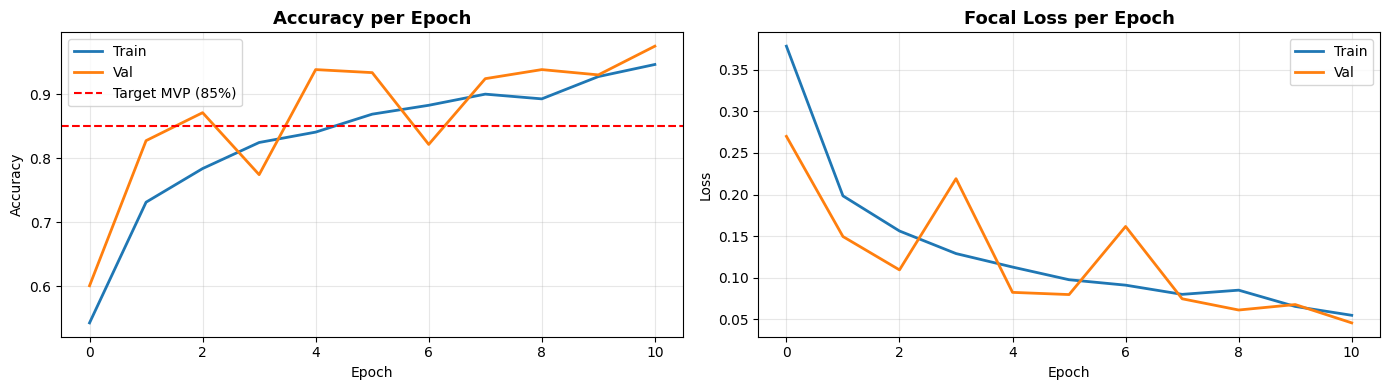

Plot tersimpan: training_history.png


In [14]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['accuracy'],     label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val',   linewidth=2)
axes[0].axhline(0.85, color='red', linestyle='--', label='Target MVP (85%)')
axes[0].set_title('Accuracy per Epoch', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val',   linewidth=2)
axes[1].set_title('Focal Loss per Epoch', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_history.png', dpi=120)
plt.show()
print("Plot tersimpan: training_history.png")

## 6. Evaluasi Performa

In [15]:
val_loss, val_acc, val_mae = model.evaluate(val_ds, verbose=0)

print("=" * 52)
print("  HASIL EVALUASI - Validation Set")
print("=" * 52)
print(f"  Val Accuracy : {val_acc:.4f}  ({val_acc*100:.2f}%)")
print(f"  Val MAE      : {val_mae:.6f}")
print(f"  Val Loss     : {val_loss:.4f}")
print("=" * 52)

acc_ok = val_acc >= 0.85
mae_ok = val_mae <= 0.02

print(f"\n  Akurasi >= 85%  : {'LULUS' if acc_ok else 'BELUM'} ({val_acc*100:.2f}%)")
print(f"  MAE <= 0.02     : {'LULUS' if mae_ok else 'BELUM'} ({val_mae:.6f})")
print(f"\n  Status MVP      : {'SEMUA TERPENUHI' if acc_ok and mae_ok else 'Perlu peningkatan'}")

  HASIL EVALUASI - Validation Set
  Val Accuracy : 0.9752  (97.52%)
  Val MAE      : 0.003369
  Val Loss     : 0.0456

  Akurasi >= 85%  : LULUS (97.52%)
  MAE <= 0.02     : LULUS (0.003369)

  Status MVP      : SEMUA TERPENUHI


              precision    recall  f1-score   support

 Ayam Goreng      0.000     0.000     0.000         0
 Ikan Goreng      0.000     0.000     0.000         0
  Mie Goreng      0.000     0.000     0.000         0
     alpukat      0.000     0.000     0.000         0
        apel      0.000     0.000     0.000         0
       bakso      0.000     0.000     0.000         0
       bayam      0.000     0.000     0.000         0
bebek_betutu      0.000     0.000     0.000         0
   gado_gado      0.000     0.000     0.000         0
       gudeg      0.000     0.000     0.000         0
       jeruk      0.000     0.000     0.000         0
     kentang      0.000     0.000     0.000         0
      mangga      0.000     0.000     0.000         0
 nasi_goreng      0.000     0.000     0.000         0
      pempek      0.000     0.000     0.000         0
      pisang      0.000     0.000     0.000         0
       rawon      0.000     0.000     0.000         0
     rendang      0.000    

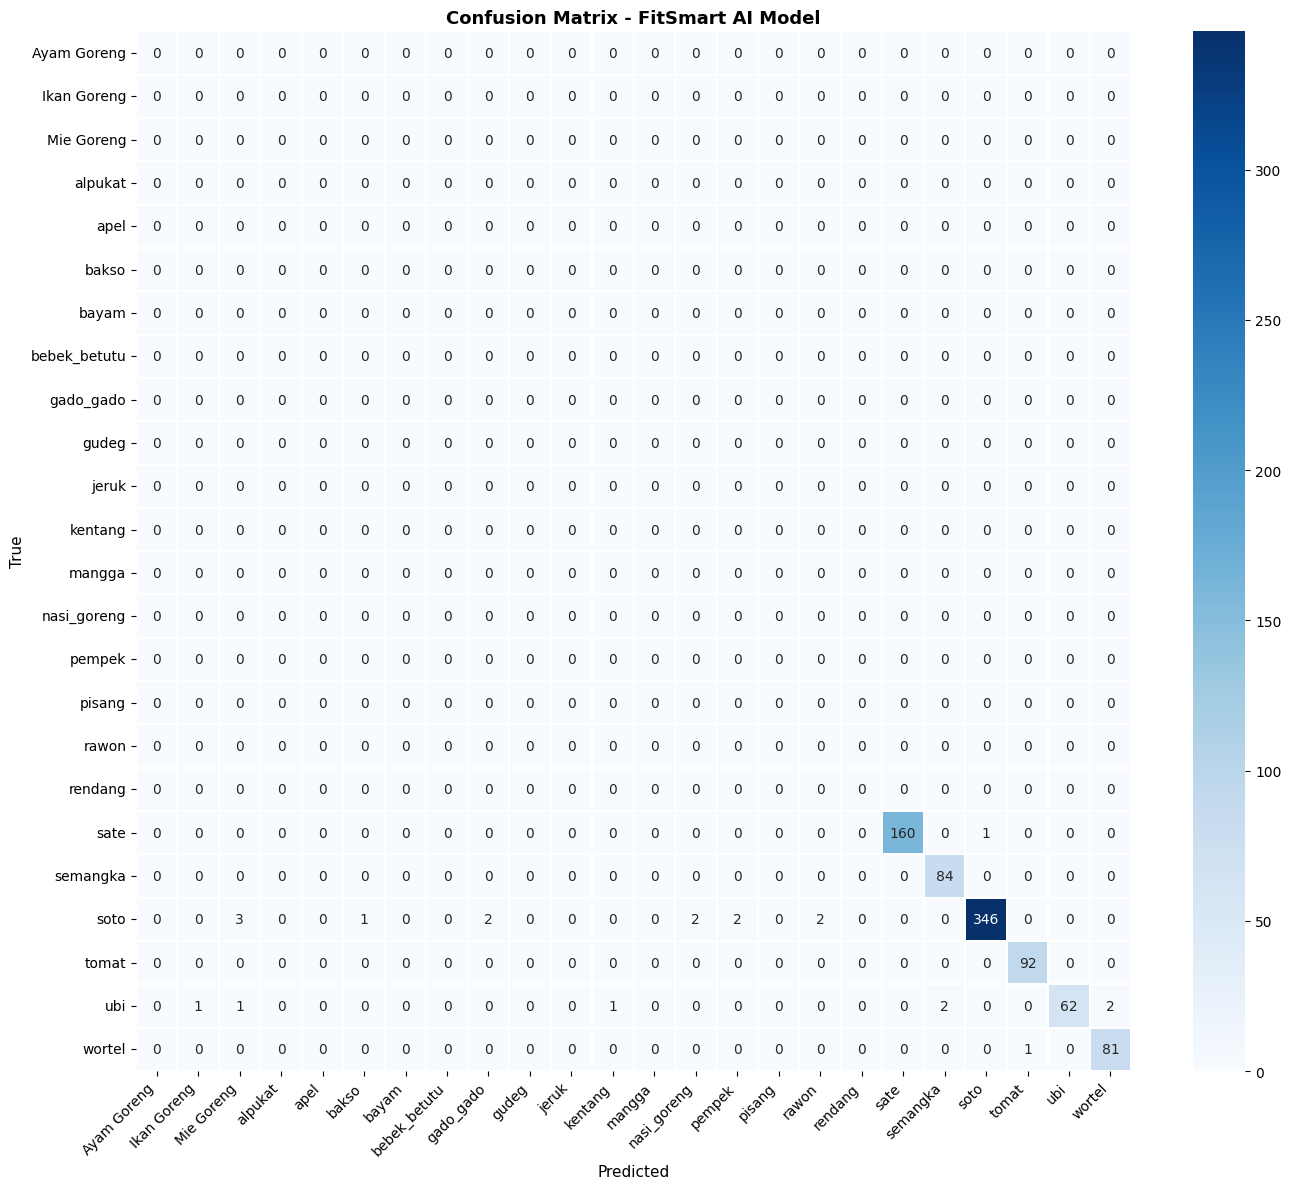

In [16]:
from sklearn.metrics import classification_report, confusion_matrix

y_true_all, y_pred_all = [], []
for images, labels in val_ds:
    probs = model.predict(images, verbose=0)
    y_pred_all.extend(np.argmax(probs, axis=1))
    y_true_all.extend(np.argmax(labels.numpy(), axis=1))

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# FIX: Create an array of all possible class indices (0 to 23)
all_class_indices = np.arange(len(CLASS_NAMES))

# Pass the 'labels' parameter to force it to recognize all 24 classes
print(classification_report(
    y_true_all,
    y_pred_all,
    labels=all_class_indices,
    target_names=CLASS_NAMES,
    digits=3,
    zero_division=0 # Prevents warnings for the missing classes
))

# Confusion matrix (also update this to keep the 24x24 shape)
cm = confusion_matrix(y_true_all, y_pred_all, labels=all_class_indices)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax,
            linewidths=0.3, linecolor='white')
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True', fontsize=11)
ax.set_title('Confusion Matrix - FitSmart AI Model', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrix.png', dpi=120)
plt.show()

## 7. Simpan & Export Model (Format Produksi)

In [ ]:
val_loss, val_acc, val_mae = model.evaluate(val_ds, verbose=0)

In [17]:
# 7a. Format .keras (rekomendasi utama)
KERAS_PATH = f'{MODEL_DIR}/fitsmart_model.keras'
model.save(KERAS_PATH)
print(f".keras tersimpan      : {KERAS_PATH}")

# 7b. SavedModel (kompatibel TF Serving / TFLite)
SAVEDMODEL_PATH = f'{MODEL_DIR}/fitsmart_savedmodel'
model.export(SAVEDMODEL_PATH)
print(f"SavedModel tersimpan  : {SAVEDMODEL_PATH}")

# 7c. class_mapping.json
mapping_out = {
    "n_classes":   N_CLASSES,
    "class_names": CLASS_NAMES,
    "cls2idx":     {c: i for i, c in enumerate(CLASS_NAMES)},
    "idx2cls":     {str(i): c for i, c in enumerate(CLASS_NAMES)},
    "nutrition":   NUTRITION,
    "img_size":    list(IMG_SIZE),
}
with open(f'{MODEL_DIR}/class_mapping.json', 'w') as f:
    json.dump(mapping_out, f, indent=2, ensure_ascii=False)

# 7d. eval_metrics.json
metrics_out = {
    "val_accuracy":   round(float(val_acc), 6),
    "val_mae":        round(float(val_mae), 6),
    "val_loss":       round(float(val_loss), 6),
    "mvp_acc_pass":   bool(val_acc >= 0.85),
    "mvp_mae_pass":   bool(val_mae <= 0.02),
    "epochs_trained": EPOCHS if 'history' not in locals() else len(history.history['accuracy']),
    "n_classes":      N_CLASSES,
    "architecture":   "MobileNetV2 + ChannelAttention (SE) + FocalLoss",
}
with open(f'{MODEL_DIR}/eval_metrics.json', 'w') as f:
    json.dump(metrics_out, f, indent=2)

print(f"\nFile model tersimpan di: {MODEL_DIR}/")
for fname in ['fitsmart_model.keras', 'fitsmart_savedmodel/', 'class_mapping.json', 'eval_metrics.json']:
    print(f"   {fname}")

.keras tersimpan      : /content/fitsmart/model/fitsmart_model.keras
Saved artifact at '/content/fitsmart/model/fitsmart_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='image_input')
Output Type:
  TensorSpec(shape=(None, 24), dtype=tf.float32, name=None)
Captures:
  139583475197968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139583475199120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139583475199312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139583475198544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139583475197008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139583475198160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139583475200848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139583475200656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139583475200272: TensorSpec(shape=(), dtype=tf.resource, n

In [20]:
# Verifikasi load ulang model
loaded_model = keras.models.load_model(
    KERAS_PATH,
    custom_objects={
        "ChannelAttention": ChannelAttention,
        "FocalLoss":        FocalLoss,
    }
)

dummy = tf.zeros((1, *IMG_SIZE, 3))
out   = loaded_model(dummy, training=False)
print(f"Model berhasil dimuat ulang dari {KERAS_PATH}")
print(f"Output shape : {out.shape}")
print(f"Sum probs    : {float(tf.reduce_sum(out)):.4f}  (harus mendekati 1.0)")

Model berhasil dimuat ulang dari /content/fitsmart/model/fitsmart_model.keras
Output shape : (1, 24)
Sum probs    : 1.0000  (harus mendekati 1.0)


## 8. Kode Inference Sederhana (Siap Produksi)

In [21]:
# ============================================================
# MODUL INFERENCE - dapat diimport langsung dari backend
# (Flask / FastAPI / Node.js via subprocess)
# ============================================================

def load_fitsmart_model(model_path: str, mapping_path: str):
    """Load model & class mapping sekali saat startup server."""
    with open(mapping_path) as f:
        mapping = json.load(f)
    mdl = keras.models.load_model(
        model_path,
        custom_objects={"ChannelAttention": ChannelAttention, "FocalLoss": FocalLoss}
    )
    return mdl, mapping


def preprocess_image(image_path: str, img_size=(224, 224)):
    """Preprocess satu gambar dari path menjadi tensor siap predict."""
    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, img_size)
    img = tf.cast(img, tf.float32) / 255.0
    return tf.expand_dims(img, axis=0)          # (1, H, W, 3)


def predict_food(model, mapping: dict, image_path: str, top_k: int = 3) -> dict:
    """
    Prediksi kelas makanan dari path gambar.

    Args:
        model      : model yang sudah dimuat
        mapping    : dict class mapping (dari class_mapping.json)
        image_path : path ke file gambar
        top_k      : jumlah prediksi teratas yang dikembalikan

    Returns:
        dict dengan kunci:
            - predicted_class : str, label prediksi teratas
            - confidence      : float, nilai kepercayaan (0-1)
            - top_predictions : list of {label, confidence, nutrition}
    """
    img      = preprocess_image(image_path, tuple(mapping["img_size"]))
    probs    = model(img, training=False).numpy()[0]
    top_idxs = np.argsort(probs)[::-1][:top_k]

    results = []
    for idx in top_idxs:
        label     = mapping["idx2cls"][str(idx)]
        conf      = float(probs[idx])
        nutrition = mapping["nutrition"].get(label, {})
        results.append({"label": label, "confidence": round(conf, 4), "nutrition": nutrition})

    return {
        "predicted_class": results[0]["label"],
        "confidence":      results[0]["confidence"],
        "top_predictions": results,
    }

print("Fungsi inference siap: load_fitsmart_model, preprocess_image, predict_food")

Fungsi inference siap: load_fitsmart_model, preprocess_image, predict_food


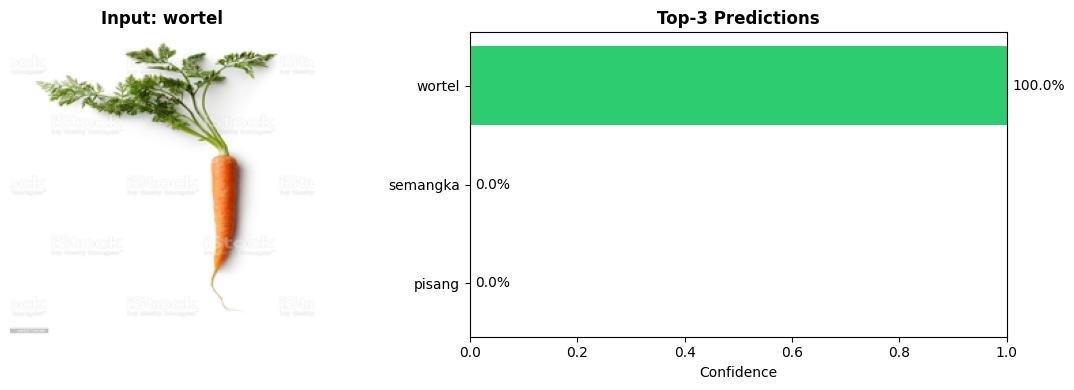


  Input (true label)  : wortel
  Prediksi teratas    : wortel (100.0%)
  Hasil              : BENAR


In [22]:
# Demo: predict 1 gambar random dari dataset
import random
from PIL import Image as PILImage

all_images = list(Path(IMAGES_DIR).rglob("*.jpg")) + list(Path(IMAGES_DIR).rglob("*.png"))

if all_images:
    sample_path = str(random.choice(all_images))
    true_label  = Path(sample_path).parent.name

    # Load model & predict
    infer_model, infer_mapping = load_fitsmart_model(
        KERAS_PATH, f'{MODEL_DIR}/class_mapping.json')
    result = predict_food(infer_model, infer_mapping, sample_path, top_k=3)

    # Visualisasi
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].imshow(PILImage.open(sample_path).resize((224, 224)))
    axes[0].set_title(f'Input: {true_label}', fontsize=12, fontweight='bold')
    axes[0].axis('off')

    labels = [p["label"] for p in result["top_predictions"]]
    confs  = [p["confidence"] for p in result["top_predictions"]]
    colors = ['#2ecc71' if l == true_label else '#3498db' for l in labels]

    axes[1].barh(labels[::-1], confs[::-1], color=colors[::-1])
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel('Confidence')
    axes[1].set_title('Top-3 Predictions', fontsize=12, fontweight='bold')
    for i, (l, c) in enumerate(zip(labels[::-1], confs[::-1])):
        axes[1].text(c + 0.01, i, f'{c:.1%}', va='center', fontsize=10)

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/inference_demo.png', dpi=120)
    plt.show()

    print(f"\n  Input (true label)  : {true_label}")
    print(f"  Prediksi teratas    : {result['predicted_class']} ({result['confidence']:.1%})")
    print(f"  Hasil              : {'BENAR' if result['predicted_class'] == true_label else 'SALAH'}")
    nut = result['top_predictions'][0]['nutrition']
    if nut:
        print(f"\n  Info Nutrisi ({result['predicted_class']}):")
        for k, v in nut.items():
            print(f"    {k:12s}: {v}")
else:
    print("Tidak ada gambar. Jalankan cell download terlebih dahulu.")

## 9. Ringkasan & Checklist MVP

In [23]:
with open(f'{MODEL_DIR}/eval_metrics.json') as f:
    metrics = json.load(f)

print("=" * 62)
print("  CHECKLIST MAIN QUEST - AI Engineer (CC26-PSU394)")
print("=" * 62)

checks = [
    ("Model TF Functional API",   True,
     "FitSmart_v1: MobileNetV2 + ChannelAttention"),
    ("Custom Layer",              True,
     "ChannelAttention (SE Block, reduction=16)"),
    ("Custom Loss Function",      True,
     "FocalLoss (gamma=2.0, alpha=0.25)"),
    ("Custom Callback",           True,
     "PerformanceGuardCallback"),
    ("Simpan .keras",             os.path.exists(KERAS_PATH),
     "fitsmart_model.keras"),
    ("Simpan SavedModel",         os.path.exists(SAVEDMODEL_PATH),
     "fitsmart_savedmodel/"),
    ("Kode Inference",            True,
     "predict_food() + load_fitsmart_model()"),
    ("Akurasi >= 85%",           metrics["mvp_acc_pass"],
     f"{metrics['val_accuracy']*100:.2f}%"),
    ("MAE <= 0.02",               metrics["mvp_mae_pass"],
     f"{metrics['val_mae']:.6f}"),
]

for label, passed, detail in checks:
    icon = "[OK]" if passed else "[--]"
    print(f"  {icon}  {label:<30s}  {detail}")

all_pass = all(p for _, p, _ in checks)
print("=" * 62)
print(f"  STATUS AKHIR : {'SEMUA TERPENUHI - SIAP SUBMIT' if all_pass else 'Ada item belum terpenuhi'}")
print("=" * 62)

  CHECKLIST MAIN QUEST - AI Engineer (CC26-PSU394)
  [OK]  Model TF Functional API         FitSmart_v1: MobileNetV2 + ChannelAttention
  [OK]  Custom Layer                    ChannelAttention (SE Block, reduction=16)
  [OK]  Custom Loss Function            FocalLoss (gamma=2.0, alpha=0.25)
  [OK]  Custom Callback                 PerformanceGuardCallback
  [OK]  Simpan .keras                   fitsmart_model.keras
  [OK]  Simpan SavedModel               fitsmart_savedmodel/
  [OK]  Kode Inference                  predict_food() + load_fitsmart_model()
  [OK]  Akurasi >= 85%                  97.52%
  [OK]  MAE <= 0.02                     0.003369
  STATUS AKHIR : SEMUA TERPENUHI - SIAP SUBMIT
